This notebook provides simple Python helper functions for computing and plotting FAST DRAG and HD DRAG pulses both in the time domain and in the frequency domain. The FAST DRAG and HD DRAG pulses are introduced in the paper "Reducing leakage of single-qubit gates for superconducting quantum processors using analytical control pulse envelopes" by Eric Hyyppä, Antti Vepsäläinen, ..., and Johannes Heinsoo. The paper was published in PRX Quantum 5, 030353 (2024). 

Here, the default pulse parameters are the same as in the paper, but they can be easily adjusted to play around with the pulse shapes.

# Imports

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

#from scipy.misc import derivative
from scipy.integrate import quad
from scipy.integrate import simpson

# Helper functions

## FAST DRAG

In [27]:
def offsetted_cosine_n(t_arr, n, tp):
    """
    Signal of the form 1 - cos(2*pi*n*t/tp).
    Inputs:
        t_arr: 1d np array of time values
        n: integer index of the basis function
        tp: pulse duration
    """
    return 1 - np.cos(2*np.pi*n*t_arr/tp)

def I_envelope_FAST_DRAG(t_arr, c_arr, tp): 
    """In-phase component of a FAST DRAG pulse, ie., a signal of the form sum_n cn * (1 - cos(2*pi*n*t/tp))
    Inputs:
        t_arr: 1d np array of time values
        c_arr: 1d np array of Fourier coefficients.
        tp: pulse duration
    """
    s_arr = np.zeros(t_arr.shape)
    for n, cn in enumerate(c_arr): 
        # Note that n starts from zero
        s_arr  = s_arr + cn * offsetted_cosine_n(t_arr, n + 1, tp)
    return s_arr

def Q_envelope_FAST_DRAG(t_arr, c_arr, tp):
    """Quadrature component of a FAST DRAG pulse, ie., derivative of the signal sum_n cn * (1 - cos(2*pi*n*t/tp)) (multiplied by (2*pi/tp))
    Inputs:
        t_arr: 1d np array of time values
        c_arr: 1d np array of Fourier coefficients.
        tp: pulse duration
    """
    s_arr = np.zeros(t_arr.shape)
    for n, cn in enumerate(c_arr): 
        s_arr = s_arr + cn * (n+1) * np.sin(2*np.pi*(n+1)*t_arr/tp)
    return s_arr

def ft_of_nth_cos_term(f_arr, tp, n): 
    """Analytically evaluated Fourier transform of 1 - cos(2*pi*n*t/tp) defined on the interval [0, tp]
    Inputs:
        f_arr: 1d np array of frequencies at which the Fourier transform is to be evaluated
        n: integer index of the basis function
        tp: pulse duration duration
    """
    # Note np.sinc = sin(pi*x)/(pi*x)
    ft_cos_nt = tp * (np.exp(-1j*np.pi*tp*f_arr)*np.sinc(tp*f_arr) 
                    - 0.5 * np.exp(1j*np.pi*(n/tp - f_arr)*tp)*np.sinc((n/tp - f_arr)*tp) 
                    -0.5 * np.exp(-1j*np.pi*(n/tp + f_arr)*tp)*np.sinc((n/tp + f_arr)*tp))
    return ft_cos_nt      

def compute_Anm(n,m, tp, weights_arr, suppr_freq_ranges_2darr):
    """ Computes the matrix element A_nm, where n,m start from the lowest frequency cosine wave with n,m=1. 
    See Eq. A5 and A6 of Appendix A. 
    Inputs:
        n: row index, >=1
        m: column index, >= 1
        tp: pulse duration
        weights_arr: 1d np array of weights of the suppressed frequency intervals used in the objective function 
        suppr_freq_ranges_2darr: 2d np array describing the frequency ranges, over which we want to suppress the Fourier transform.
                                 The array should have two columns, the first giving the starting frequency for each range and the 
                                 second giving the ending frequency for each range. Each row corresponds to a different frequency interval.
                                 Note that the frequencies are defined in the baseband, i.e., with respect to the central drive frequency. 
                                 The spectrum will be symmetrically suppressed as discussed in the manuscript.
    
    """
    A_nm = 0.0
    N_ranges = len(weights_arr)
    for i_range in range(N_ranges):
        w_i = weights_arr[i_range]
        f_start = suppr_freq_ranges_2darr[i_range, 0]
        f_end = suppr_freq_ranges_2darr[i_range, 1]
        fun_to_int = lambda f:  ft_of_nth_cos_term(f, tp, n) * np.conjugate(ft_of_nth_cos_term(f, tp, m))
        fun_to_int_r = lambda f:  np.real(fun_to_int(f))
        fun_to_int_i = lambda f:  np.imag(fun_to_int(f))
        A_nm += w_i * (quad(fun_to_int_r, f_start, f_end)[0] + 1.0j*quad(fun_to_int_i, f_start, f_end)[0])
    return A_nm

def solve_optimal_coefs_for_given_w_and_ranges(N, tp, rot_angle, weights_arr, suppr_freq_ranges_2darr):
    """ Computes the optimal coefficients of the cosine series to suppress the spectrum across the given frequency intervals 
    based on the provided weights. See Eq. (5) of Sec. IIB and Appendix A. 
    N: number of cosine terms included in the cosine series, N >= 2
    tp: pulse duration
    rot_angle: targeted rotation angle in rad, i.e., the area under the pulse
    weights_arr: 1d np array of weights of the suppressed frequency intervals used in the objective function 
    suppr_freq_ranges_2darr: 2d np array describing the frequency ranges, over which we want to suppress the Fourier transform.
                                 The array should have two columns, the first giving the starting frequency for each range and the 
                                 second giving the ending frequency for each range. Each row corresponds to a different frequency interval.
                                 Note that the frequencies are defined in the baseband, i.e., with respect to the central drive frequency. 
                                 The spectrum will be symmetrically suppressed as discussed in the manuscript.
    
    """
    # Construct matrix A_tilde = [A + A^T, -b; b^T, 0] and vector b = [0; A_theta/tp] for solving the 
    # optimal coefficients
    A_tilde = np.zeros((N+1, N+1), dtype=complex)
    b_vect = np.zeros((N+1,), dtype=complex)
    ones_vect = np.ones((N,))
    A_mat = np.zeros((N, N), dtype=complex)
    #Construct matrix A_mat needed for A_tilde
    for n in range(N):
        #Note: index 0 of A_mat corresponds to the 1st cosine wave
        for m in range(N):
            A_mat[n,m] = compute_Anm(n+1,m+1, tp, weights_arr, suppr_freq_ranges_2darr)
    #Construct A_tilde
    A_tilde[0:N,0:N] = A_mat + np.transpose(A_mat)
    A_tilde[0:N, N] = -ones_vect
    A_tilde[N, 0:N] = ones_vect
    #print(A_tilde)
    #Construct b vector
    b_vect[N] = rot_angle / tp
    c_opt_full = np.linalg.solve(A_tilde, b_vect)
    #Note that the last element of c_opt is the Lagrangian multiplier that is not of our interest
    c_opt = c_opt_full[0:N]
    #print(c_opt)
    return np.real(c_opt)

## HD DRAG 

In [28]:
def compute_beta2_from_suppr_freq(suppressed_frequency, tp):
    """Compute beta2 for a given suppressed_frequency and pulse duration. Here, we have absorbed a factor of (2*pi)^2/tp^2 
    to the beta2-coefficient compared to Eqs. (6) and (7) of Sec. IIC to make beta2 a unitless quantity 
    on the order of unity and to comply with our below-given definition of the derivatives  
    Inputs:
        suppressed_frequency: suppressed frequency (w.r.t center drive frequency)
        tp: pulse duration
    """
    return 1 / (2 * np.pi * suppressed_frequency * tp / (2*np.pi)) ** 2

def compute_suppr_freq_from_beta2(beta2, tp):
    """Compute suppressed_frequency from beta2 and pulse duration.
    Inputs:
        beta2: beta2-coefficient
        tp: pulse duration
    """
    if beta2 == 0.0:
        return np.inf
    else:
        return 1 / (2 * np.pi * np.sqrt(beta2) * tp / (2*np.pi))
    
def cos_sum_Dn(t_arr, tp, n):
    """nth derivative of a cosine sum given in Sec. IIC. The coefficients of the cosine sum have been chosen 
    s.t. the derivatives are continuous up to the 3rd derivative. 
    Inputs:
        t_arr: 1d np array of times
        tp: pulse duration
    """
    # Derivatives scaled by (T/2pi)**n
    cos_t = np.cos(2*np.pi*t_arr/tp)
    cos_2t = np.cos(4*np.pi*t_arr/tp)
    sin_t  = np.sin(2*np.pi*t_arr/tp)
    sin_2t  = np.sin(4*np.pi*t_arr/tp)
    if n == 0:
        f = 3/8 * (1 - 4/3 * cos_t + 1/3 * cos_2t)
    elif n == 1: 
        f = 3/8 * (4/3 * sin_t - 2/3 * sin_2t)
    elif n == 2: 
        f = 3/8 * (4/3 * cos_t - 4/3 * cos_2t)
    else:
        f = 3/8 * (-4/3 * sin_t + 8/3 * sin_2t)
    return f

def I_envelope_HD_DRAG(t_arr, beta2, tp): 
    """In-phase component of a HD DRAG pulse
    Inputs:
        t_arr: 1d np array of time values
        beta2: beta2-parameter of HD DRAG
        tp: pulse duration 
    """
    s_arr = cos_sum_Dn(t_arr, tp, 0) + beta2*cos_sum_Dn(t_arr, tp, 2)
    return s_arr

def Q_envelope_HD_DRAG(t_arr, beta2, tp):
    """Quadrature component of a HD DRAG pulse, i.e., derivative of the I-envelope (multiplied by (2*pi/tp))
    Inputs:
        t_arr: 1d np array of time values
        beta2: beta2-parameter of HD DRAG
        tp: pulse duration 
    """
    s_arr = cos_sum_Dn(t_arr, tp, 1) + beta2*cos_sum_Dn(t_arr, tp, 3)
    return s_arr

## Cosine DRAG

In [29]:
def I_envelope_cos_DRAG(t_arr, tp): 
    """In-phase component of a cosine DRAG pulse
    Inputs:
        t_arr: 1d np array of time values
        tp: pulse duration 
    """
    s_arr = 1 - np.cos(2*np.pi*t_arr/tp)
    return s_arr

def Q_envelope_cos_DRAG(t_arr, tp):
    """Quadrature component of a cosine DRAG pulse, i.e., derivative of the I-envelope (multiplied by (2*pi/tp))
    Inputs:
        t_arr: 1d np array of time values
        tp: pulse duration 
    """
    s_arr = np.sin(2*np.pi*t_arr/tp)
    return s_arr


## Fourier transform

In [30]:
def compute_fft(t_arr, s_arr):
    """Compute fft of a pulse s_arr 
    Inputs:
        t_arr: 1d np array of time values
        s_arr: signal values evaluated at t_arr
    Outputs: 
        f_arr: 1d np array of frequencies
        fft_s: fft of signal s_arr as 1d np array
    """
    N_s = len(t_arr)
    f_s = 1 / (t_arr[1] - t_arr[0])
    tg = t_arr[-1]

    # Add zero padding to make the frequency grid have smaller spacing
    N_z = 20*len(t_arr)
    tz = N_z/f_s
    t_arr_z = np.linspace(tg + 1/f_s, tg + tz, N_z)
    s_z = np.zeros((N_z,))

    t_arr_tot = np.concatenate((t_arr, t_arr_z))
    s = np.concatenate((s_arr, s_z))

    #Total number of samples
    N_s_tot = N_s + N_z

    # Take fft
    #fft
    fft_s_cmplx = 1/f_s * np.fft.fftshift(np.fft.fft(s)) # multiplying by step size to get normalization agree with the integral F transform
    fft_s = np.abs(fft_s_cmplx)
    f_arr = np.fft.fftshift(np.fft.fftfreq(N_s_tot, d=1/f_s))
    
    return f_arr, fft_s

def compute_fft_of_IQ_pulse(t_arr, I_arr, Q_arr, drive_freq):
    """Compute fft of an (upconverted) IQ-pulse upconverted to a center drive frequency of drive_freq
    Inputs:
        t_arr: 1d np array of time values
        I_arr: 1d np array of in-phase component of the pulse
        Q_arr: 1d np array of quadrature component of the pulse
        drive_freq: center drive frequency
    Outputs: 
        f_arr: 1d np array of frequencies
        fft_s: fft of signal s_arr as 1d np array
    """
    N_s = len(t_arr)
    f_s = 1 / (t_arr[1] - t_arr[0])
    tg = t_arr[-1]
    
    #Signal at the drive frequency
    s_arr = I_arr*np.cos(2*np.pi*drive_freq*t_arr) + Q_arr*np.sin(2*np.pi*drive_freq*t_arr)
    
    # Add zero padding to make the frequency grid have smaller spacing
    N_z = 80*len(t_arr)
    tz = N_z/f_s
    t_arr_z = np.linspace(tg + 1/f_s, tg + tz, N_z)
    s_z = np.zeros((N_z,))

    t_arr_tot = np.concatenate((t_arr, t_arr_z))
    s = np.concatenate((s_arr, s_z))

    #Total number of samples
    N_s_tot = N_s + N_z
    
    # Take fft
    #fft
    fft_s_cmplx = 1/f_s * np.fft.fftshift(np.fft.fft(s)) # multiplying by step size to get normalization agree with the integral F transform
    fft_s = np.abs(fft_s_cmplx)
    f_arr = np.fft.fftshift(np.fft.fftfreq(N_s_tot, d=1/f_s))
    
    return f_arr, fft_s

# Illustrating FAST DRAG and HD DRAG pulses

We use nanoseconds as our time unit and correspondingly GHz as the frequency unit

In [31]:
#Colors
light_blue = [0.3010, 0.7450, 0.9330]
dark_blue = [51/255,51/255,255/255] #[65,105,225]/255; %royal blue
crimson = [220/255, 20/255, 60/255] 
light_red = [240/255,128/255,128/255]
light_green = [50/255,205/255,50/255]
dark_green = [0/255,100/255,0/255]
dark_grey = [80/255, 80/255, 80/255]
dark_orange = [255/255, 128/255, 0]
light_orange = [255/255, 204/255, 153/255]

In [32]:
# Use the anharmonicity from the paper
anharmonicity = -0.212 # GHz

#Pulse duration
tp = 6 # ns
N_s = 1000
t_arr = np.linspace(0, tp, N_s)

## Time-domain

### FAST DRAG

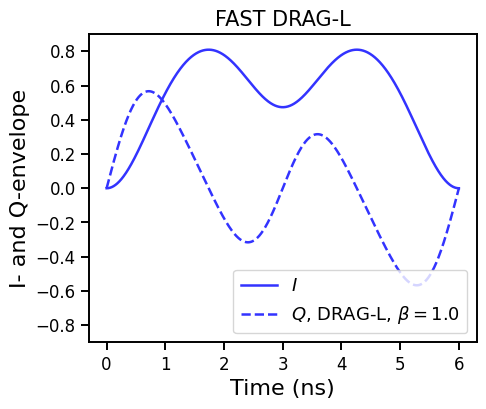

In [33]:
#Define hyperparameters
N = 4 # number of cosine waves in the series
weights_arr = np.array([5, 1]) # weights for the FAST objective function
# Suppressed (baseband) frequency intervals. Here, we use parameters from the main text of the paper.
# The first interval suppresses the ef-transition, whereas the second regularizes the pulse shape by providing a cutoff frequency.
# The upper limit of the 2nd interval is set to some large value, here 2 GHz.
suppr_freq_ranges_2darr = np.array([[np.abs(anharmonicity)-18e-3, np.abs(anharmonicity)+2e-3], 
                                    [450e-3, 2000e-3]]) 
rot_angle = np.pi # targeted rotation angle for normalizing the pulse area

#Compute optimal coefficients of the cosine series.
c_opt = solve_optimal_coefs_for_given_w_and_ranges(N, tp, rot_angle, weights_arr, suppr_freq_ranges_2darr)

#I-envelope in time domain
sI_FAST_DRAG_arr = I_envelope_FAST_DRAG(t_arr, c_opt, tp)

#Q-envelope for FAST DRAG
#beta = 0.5 # DRAG-P
beta = 1.0 # DRAG-L
mult_factor = -beta * 2 * np.pi / (tp*2*np.pi*anharmonicity)
sQ_FAST_DRAG_arr = mult_factor * Q_envelope_FAST_DRAG(t_arr, c_opt, tp)

fig, ax = plt.subplots(1, 1, figsize=(5,4))
plt.plot(t_arr,sI_FAST_DRAG_arr, label = r'$I$', color=dark_blue, linewidth=1.8)#
plt.plot(t_arr, sQ_FAST_DRAG_arr,  '--', label = r'$Q$, DRAG-L, $\beta = 1.0$', color=dark_blue, linewidth=1.8)#
plt.xlabel('Time (ns)', fontsize = 16)
plt.ylabel('I- and Q-envelope', fontsize = 16)
plt.legend(fontsize = 13, loc='lower right')
plt.title('FAST DRAG-L', fontsize = 15)
#plt.title(prefix_str)
plt.ylim([-0.9, 0.9])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.tick_params(length=6, width = 1.4)
for side in ['top', 'left', 'right', 'bottom']:
    ax.spines[side].set_linewidth(1.4)

### HD DRAG

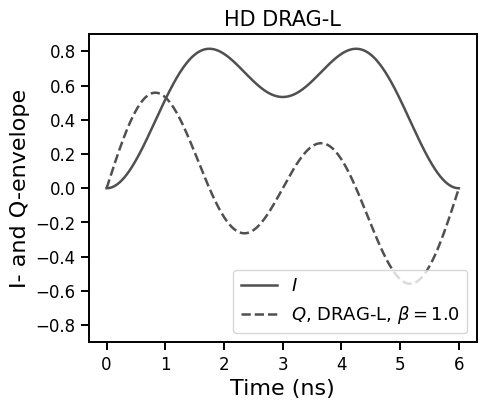

In [34]:
# Obtain beta2 by suppressing the baseband spectrum at anharmonicity
beta2 = compute_beta2_from_suppr_freq(np.abs(anharmonicity), tp)

#I-envelope in time domain
amp = np.pi/simpson(I_envelope_HD_DRAG(t_arr, beta2, tp), x=t_arr) #fix rotation angle to pi
sI_HD_DRAG_arr = amp*I_envelope_HD_DRAG(t_arr, beta2, tp)

#Q-envelope for FAST DRAG
#beta = 0.5 # DRAG-P
beta = 1.0 # DRAG-L
mult_factor = -beta * 2 * np.pi / (tp*2*np.pi*anharmonicity)
sQ_HD_DRAG_arr = amp*mult_factor * Q_envelope_HD_DRAG(t_arr, beta2, tp)

fig, ax = plt.subplots(1, 1, figsize=(5,4))
plt.plot(t_arr, sI_HD_DRAG_arr, label = r'$I$', color=dark_grey, linewidth=1.8)#
plt.plot(t_arr, sQ_HD_DRAG_arr,  '--', label = r'$Q$, DRAG-L, $\beta = 1.0$', color=dark_grey, linewidth=1.8)#
plt.xlabel('Time (ns)', fontsize = 16)
plt.ylabel('I- and Q-envelope', fontsize = 16)
plt.legend(fontsize = 13, loc='lower right')
plt.title('HD DRAG-L', fontsize = 15)
#plt.title(prefix_str)
plt.ylim([-0.9, 0.9])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.tick_params(length=6, width = 1.4)
for side in ['top', 'left', 'right', 'bottom']:
    ax.spines[side].set_linewidth(1.4)



### Cosine DRAG

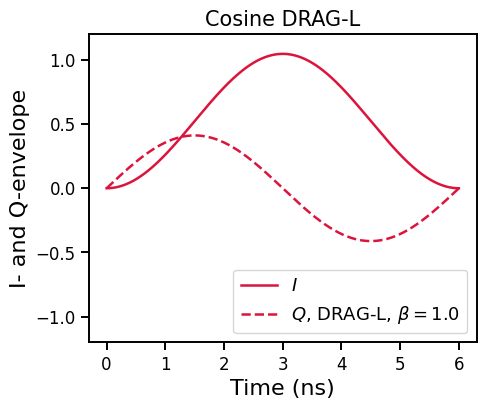

In [35]:
#I-envelope in time domain
amp = np.pi/simpson(I_envelope_cos_DRAG(t_arr, tp), x=t_arr) #fix rotation angle to pi
sI_cos_DRAG_arr = amp*I_envelope_cos_DRAG(t_arr, tp)

#Q-envelope for FAST DRAG
#beta = 0.5 # DRAG-P
beta = 1.0 # DRAG-L
mult_factor = -beta * 2 * np.pi / (tp*2*np.pi*anharmonicity)
sQ_cos_DRAG_arr = amp*mult_factor * Q_envelope_cos_DRAG(t_arr, tp)


fig, ax = plt.subplots(1, 1, figsize=(5,4))
plt.plot(t_arr, sI_cos_DRAG_arr, label = r'$I$', color=crimson, linewidth=1.8)#
plt.plot(t_arr, sQ_cos_DRAG_arr,  '--', label = r'$Q$, DRAG-L, $\beta = 1.0$', color=crimson, linewidth=1.8)#
plt.xlabel('Time (ns)', fontsize = 16)
plt.ylabel('I- and Q-envelope', fontsize = 16)
plt.legend(fontsize = 13, loc='lower right')
plt.title('Cosine DRAG-L', fontsize = 15)
#plt.title(prefix_str)
plt.ylim([-1.2, 1.2])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.tick_params(length=6, width = 1.4)
for side in ['top', 'left', 'right', 'bottom']:
    ax.spines[side].set_linewidth(1.4)



## Frequncy-domain

### Fourier transform of I-envelopes

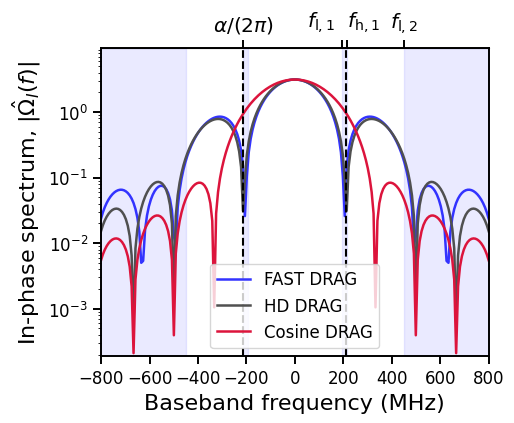

In [36]:
# FAST DRAG
f_arr_FAST_DRAG, fft_sI_FAST_DRAG = compute_fft(t_arr, sI_FAST_DRAG_arr)

# HD DRAG
f_arr_HD_DRAG, fft_sI_HD_DRAG = compute_fft(t_arr, sI_HD_DRAG_arr)

# Cosine DRAG
f_arr_cos_DRAG, fft_sI_cos_DRAG = compute_fft(t_arr, sI_cos_DRAG_arr)

# Fourier transform of I for the different pulses
fig, ax = plt.subplots(1, 1, figsize=(5,4))
plt.semilogy(f_arr_FAST_DRAG*1e3, fft_sI_FAST_DRAG, '-', label='FAST DRAG', color=dark_blue, linewidth=1.8)
plt.semilogy(f_arr_HD_DRAG*1e3, fft_sI_HD_DRAG, '-', label = 'HD DRAG', color=dark_grey, linewidth=1.8)
plt.semilogy(f_arr_cos_DRAG*1e3, fft_sI_cos_DRAG, '-', label = 'Cosine DRAG', color=crimson, linewidth=1.8)
y_max = 3*max([np.max(fft_sI_FAST_DRAG)])
y_min = y_max / 5e4
# We illustrate the suppressed frequency intervals and anharmonicity
plt.plot([anharmonicity*1e3, anharmonicity*1e3], [y_min, y_max], '--', color='k', linewidth=1.5)
plt.plot([-anharmonicity*1e3, -anharmonicity*1e3], [y_min, y_max], '--', color='k', linewidth=1.5)
suppr_width = suppr_freq_ranges_2darr[0,1] -suppr_freq_ranges_2darr[0,0]
suppr_width_2 = suppr_freq_ranges_2darr[1,1] -suppr_freq_ranges_2darr[1,0]
ax.add_patch(Rectangle((suppr_freq_ranges_2darr[0,0]*1e3, y_min), 1e3*suppr_width, y_max-y_min,alpha=0.1, color=dark_blue))
ax.add_patch(Rectangle((-suppr_freq_ranges_2darr[0,1]*1e3, y_min), 1e3*suppr_width, y_max-y_min,alpha=0.1, color=dark_blue))
ax.add_patch(Rectangle((suppr_freq_ranges_2darr[1,0]*1e3, y_min), 1e3*suppr_width_2, y_max-y_min,alpha=0.1, color=dark_blue))
ax.add_patch(Rectangle((-suppr_freq_ranges_2darr[1,1]*1e3, y_min), 1e3*suppr_width_2, y_max-y_min,alpha=0.1, color=dark_blue))
plt.xlabel('Baseband frequency (MHz)', fontsize = 16)
plt.ylabel(r'In-phase spectrum, $|\hat{\Omega}_I(f)|$', fontsize = 16)
plt.legend(fontsize = 12, loc='lower center')
xmin = -0.8*1e3
xmax = 0.8*1e3
def f2f(x):
    return x
secax = ax.secondary_xaxis('top', functions=(f2f, f2f))
secax.tick_params(length=6, width = 1.4, labelsize=13)
secax.set_xticks([anharmonicity*1e3, suppr_freq_ranges_2darr[0,0]*1e3, suppr_freq_ranges_2darr[0,1]*1e3, suppr_freq_ranges_2darr[1,0]*1e3])
secax.set_xticklabels([r"$\alpha/(2\pi)$", '', '', r'$f_{\mathrm{l}, 2}$'], fontsize=14.5)
ax.text(suppr_freq_ranges_2darr[0,0]*1e3-145, 20, r'$f_{\mathrm{l}, \mathrm{1}}$', {'color': 'k', 'fontsize': 14.5})
ax.text(suppr_freq_ranges_2darr[0,1]*1e3+0, 20, r'$f_{\mathrm{h}, \mathrm{1}}$', {'color': 'k', 'fontsize': 14.5})

plt.xlim([xmin, xmax])
plt.ylim(([y_min, y_max]))
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.tick_params(length=6, width = 1.4)
for side in ['top', 'left', 'right', 'bottom']:
    ax.spines[side].set_linewidth(1.4)

### Fourier transform of full IQ pulse

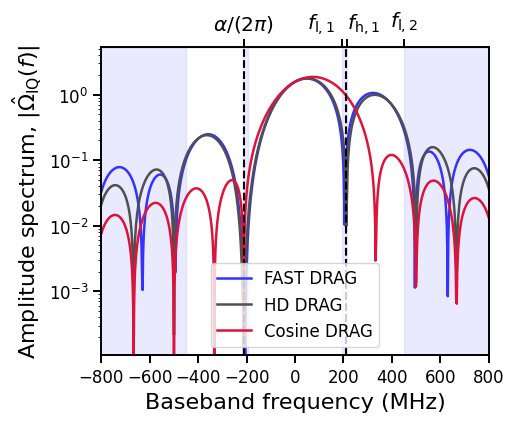

In [37]:
# FAST DRAG
drive_freq = 4.5
f_arr_FAST_DRAG, fft_sI_FAST_DRAG = compute_fft_of_IQ_pulse(t_arr, sI_FAST_DRAG_arr, sQ_FAST_DRAG_arr, drive_freq)

# HD DRAG
f_arr_HD_DRAG, fft_sI_HD_DRAG = compute_fft_of_IQ_pulse(t_arr, sI_HD_DRAG_arr, sQ_HD_DRAG_arr, drive_freq)

# Cosine DRAG
f_arr_cos_DRAG, fft_sI_cos_DRAG = compute_fft_of_IQ_pulse(t_arr, sI_cos_DRAG_arr, sQ_cos_DRAG_arr, drive_freq)

# Fourier transform for the different pulses
fig, ax = plt.subplots(1, 1, figsize=(5,4))
plt.semilogy((f_arr_FAST_DRAG - drive_freq)*1e3, fft_sI_FAST_DRAG, '-', label='FAST DRAG', color=dark_blue, linewidth=1.8)
plt.semilogy((f_arr_FAST_DRAG - drive_freq)*1e3, fft_sI_HD_DRAG, '-', label = 'HD DRAG', color=dark_grey, linewidth=1.8)
plt.semilogy((f_arr_FAST_DRAG - drive_freq)*1e3, fft_sI_cos_DRAG, '-', label = 'Cosine DRAG', color=crimson, linewidth=1.8)
y_max = 3*max([np.max(fft_sI_FAST_DRAG)])
y_min = y_max / 5e4
# We illustrate the suppressed intervals and anharmonicity
plt.plot([anharmonicity*1e3, anharmonicity*1e3], [y_min, y_max], '--', color='k', linewidth=1.5)
plt.plot([-anharmonicity*1e3, -anharmonicity*1e3], [y_min, y_max], '--', color='k', linewidth=1.5)
suppr_width = suppr_freq_ranges_2darr[0,1] -suppr_freq_ranges_2darr[0,0]
suppr_width_2 = suppr_freq_ranges_2darr[1,1] -suppr_freq_ranges_2darr[1,0]
ax.add_patch(Rectangle((suppr_freq_ranges_2darr[0,0]*1e3, y_min), 1e3*suppr_width, y_max-y_min,alpha=0.1, color=dark_blue))
ax.add_patch(Rectangle((-suppr_freq_ranges_2darr[0,1]*1e3, y_min), 1e3*suppr_width, y_max-y_min,alpha=0.1, color=dark_blue))
ax.add_patch(Rectangle((suppr_freq_ranges_2darr[1,0]*1e3, y_min), 1e3*suppr_width_2, y_max-y_min,alpha=0.1, color=dark_blue))
ax.add_patch(Rectangle((-suppr_freq_ranges_2darr[1,1]*1e3, y_min), 1e3*suppr_width_2, y_max-y_min,alpha=0.1, color=dark_blue))
plt.xlabel('Baseband frequency (MHz)', fontsize = 16)
plt.ylabel(r'Amplitude spectrum, $|\hat{\Omega}_\mathrm{IQ}(f)|$', fontsize = 16)
plt.legend(fontsize = 12, loc='lower center')
xmin = -0.8*1e3
xmax = 0.8*1e3
def f2f(x):
    return x
secax = ax.secondary_xaxis('top', functions=(f2f, f2f))
secax.tick_params(length=6, width = 1.4, labelsize=13)
secax.set_xticks([anharmonicity*1e3, suppr_freq_ranges_2darr[0,0]*1e3, suppr_freq_ranges_2darr[0,1]*1e3, suppr_freq_ranges_2darr[1,0]*1e3])
secax.set_xticklabels([r"$\alpha/(2\pi)$", '', '', r'$f_{\mathrm{l}, 2}$'], fontsize=14.5)
ax.text(suppr_freq_ranges_2darr[0,0]*1e3-145, 10, r'$f_{\mathrm{l}, \mathrm{1}}$', {'color': 'k', 'fontsize': 14.5})
ax.text(suppr_freq_ranges_2darr[0,1]*1e3+0, 10, r'$f_{\mathrm{h}, \mathrm{1}}$', {'color': 'k', 'fontsize': 14.5})

plt.xlim([xmin, xmax])
plt.ylim(([y_min, y_max]))
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.tick_params(length=6, width = 1.4)
for side in ['top', 'left', 'right', 'bottom']:
    ax.spines[side].set_linewidth(1.4)

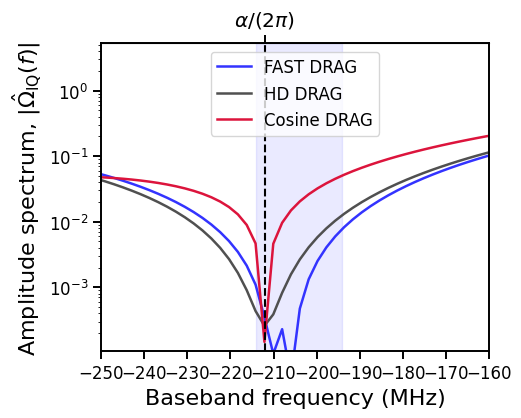

In [38]:
# Zoom around anharmonicity
fig, ax = plt.subplots(1, 1, figsize=(5,4))
plt.semilogy((f_arr_FAST_DRAG - drive_freq)*1e3, fft_sI_FAST_DRAG, '-', label='FAST DRAG', color=dark_blue, linewidth=1.8)
plt.semilogy((f_arr_FAST_DRAG - drive_freq)*1e3, fft_sI_HD_DRAG, '-', label = 'HD DRAG', color=dark_grey, linewidth=1.8)
plt.semilogy((f_arr_FAST_DRAG - drive_freq)*1e3, fft_sI_cos_DRAG, '-', label = 'Cosine DRAG', color=crimson, linewidth=1.8)
y_max = 3*max([np.max(fft_sI_FAST_DRAG)])
y_min = y_max / 5e4
plt.plot([anharmonicity*1e3, anharmonicity*1e3], [y_min, y_max], '--', color='k', linewidth=1.5)
plt.plot([-anharmonicity*1e3, -anharmonicity*1e3], [y_min, y_max], '--', color='k', linewidth=1.5)
suppr_width = suppr_freq_ranges_2darr[0,1] -suppr_freq_ranges_2darr[0,0]
suppr_width_2 = suppr_freq_ranges_2darr[1,1] -suppr_freq_ranges_2darr[1,0]
ax.add_patch(Rectangle((suppr_freq_ranges_2darr[0,0]*1e3, y_min), 1e3*suppr_width, y_max-y_min,alpha=0.1, color=dark_blue))
ax.add_patch(Rectangle((-suppr_freq_ranges_2darr[0,1]*1e3, y_min), 1e3*suppr_width, y_max-y_min,alpha=0.1, color=dark_blue))
ax.add_patch(Rectangle((suppr_freq_ranges_2darr[1,0]*1e3, y_min), 1e3*suppr_width_2, y_max-y_min,alpha=0.1, color=dark_blue))
ax.add_patch(Rectangle((-suppr_freq_ranges_2darr[1,1]*1e3, y_min), 1e3*suppr_width_2, y_max-y_min,alpha=0.1, color=dark_blue))
plt.xlabel('Baseband frequency (MHz)', fontsize = 16)
plt.ylabel(r'Amplitude spectrum, $|\hat{\Omega}_\mathrm{IQ}(f)|$', fontsize = 16)
plt.legend(fontsize = 12, loc='upper center')
xmin = -0.25*1e3
xmax = -0.16*1e3
def f2f(x):
    return x
secax = ax.secondary_xaxis('top', functions=(f2f, f2f))
secax.tick_params(length=6, width = 1.4, labelsize=13)
secax.set_xticks([anharmonicity*1e3])
secax.set_xticklabels([r"$\alpha/(2\pi)$"], fontsize=14.5)

plt.xlim([xmin, xmax])
plt.ylim(([y_min, y_max]))
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.tick_params(length=6, width = 1.4)
for side in ['top', 'left', 'right', 'bottom']:
    ax.spines[side].set_linewidth(1.4)